**Contents**<a id='toc0_'></a>    
- 1. [Single shocks](#toc1_)    
- 2. [Stochastic Shocks](#toc2_)    
- 3. [Persistent, stochastic shocks (AR)](#toc3_)    
  - 3.1. [Demand shocks as an AR-process](#toc3_1_)    
  - 3.2. [Supply shocks as an AR-process](#toc3_2_)    
- 4. [The super, social planner, living in an AR-world](#toc4_)    
  - 4.1. [Social planner with supply shocks as an AR-process](#toc3_1_)    
  - 4.2. [Social planner with demand shocks as an AR-process](#toc3_2_)    
<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# AS-AD model for an open economy with flexible inflation targetting

In [1]:
import numpy as np
import scipy
from ASADmodel import ASAD_class
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%load_ext autoreload
%autoreload 2


The AS-AD model we will be analyzing consist of the following 8 equations. We omit the time subscript where, $\beta _1, \beta _2, b, h, \gamma, \bar{y}, \pi^*$ are the time independent parameters:

**Goods market equilibrium** for an open economy: 

$$ y- \bar{y} = \beta _1 (e^r_{-1}+\Delta e + \pi^f-\pi)-\beta _2 (i-\pi^e_{+1} -\bar{r})+\tilde{z} \tag{1}$$

The aggregate demand are an increasing function of the real exchange rate, and demand shocks $\tilde{z}$, and a negative function of the real rate of return.

**Inflationexpectations** are defined as:

$$\pi_{+1}^e = \pi^e = \pi^f \tag{2}$$

Which says that the expected inflation are equal to the foreign inflation. 

**The taylor rule**: 

$$ i = r^f+\pi_{+1}^e+h(\pi-\pi^f)+b(y-\bar{y}), b>0 \tag{3}$$

Which describes how the Central Bank adjusts the nominal interest rate, as a response to higher/lower inflation compared to the foreign country, and positive/negative outputgap, through the parameters, h,b, respectively. This is the flexible inflation targetting version of the Taylor Rule. 

**The Uncovered Interest Parity (UIP)**: 
$$ i = i^f+\Delta e_{+1}^e \tag{4}$$

Which is an arbitrage condition, that says the return on investment from investing domestically should be equal to the return from exchanging the currency and investing foreignly and exchanging back. It is *uncovered* due to fact that the investor faces risk due to relying on the excepted rate. In the long run the interest rates across borders are equal since we assume the exchange rates are constant. 

**The nominal exchange rate expectations**: 

$$ \Delta e_{+1}^e = -\theta {\Delta e} \tag{5}$$

**The foreign fischer rule** or the foreign real rate: 
$$ r^f = i^f - \pi ^f \tag{6}$$

**The SRAS curve**: 
$$ \pi = \pi^e+\gamma(y-\bar{y})+s \tag{7}$$

**The real exchange rate**: 

$$e^r = e^r_{t-1} + \Delta e + \pi^f - \pi \tag{8}$$


From simple algebra, we find the three main equation of the models:

$$y_t-\bar{y} = \frac{\beta_1}{1+\beta_1 \frac
{b}{\theta}+\beta_2 b}e^r_{t-1} - \frac{\hat{\beta}_1}{1+\beta_1 \frac
{b}{\theta}+\beta_2 b}(\pi_t-\pi^f)+\frac
{1}{1+\beta_1\frac{b}{\theta} +\beta_2 b}z_t$$

$$\pi_t = \pi^f +\gamma (y_t-\bar{y})+s_t$$
$$e^r_{t} = e^r_{t-1} - \left(1+\frac{h}{\theta}\right) (\pi_t-\pi^f) -\frac{b}{\theta} (y_t-\bar{y})$$

On gap-form such that, $y-\bar{y}=\hat{y}$ and similar for $\pi$, and using $\hat{\beta}_2=1+\beta_1 \frac
{b}{\theta}+\beta_2 b$, we get:
$$\hat{y}_t = \frac{\beta_1}{\hat{\beta}_2}e^r_{t-1} - \frac{\hat{\beta}_1}{\hat{\beta}_2}\hat{\pi}+\frac
{1}{\hat{\beta}_2}z_t \tag{AD}$$
$$\hat{\pi}_t = \gamma \hat{y}_t+s_t \tag{AS}$$
$$e^r_{t} = e^r_{t-1} - \left(1+\frac{h}{\theta} \right) \hat{\pi}_t -\frac{b}{\theta} \hat{y}_t$$

These three equations describes an open economy with floating exchange rates, where the Central Bank reacts to outputgaps and inflationtarget differences, through $h$ and $b$, by monetary policy, namely nominal interest rate adjustments. 

Compared to the fixed exchange policy, the CB can freely set the nominal interest rate at the cost of changes in the nominal exchange rate flowing freely, such that the UIP is fulfilled. 

Setting $h=b=0$ we get an economy running a fixed rate policy. 

Setting $b=0$, the model collapses to an AS-AD economy with floating exchange rates and strict inflation target policy, as seen in Macroeconomics II at KU. 

In [2]:
model = ASAD_class()
par = model.par
path = model.path

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


## 1. <a id='toc1_'></a>[Single shocks](#toc0_)

First, we model a constant demand shock happening from in period 1 to period 100. 

In [3]:
model.shocks(1,100,1,z=True)
model.solve()

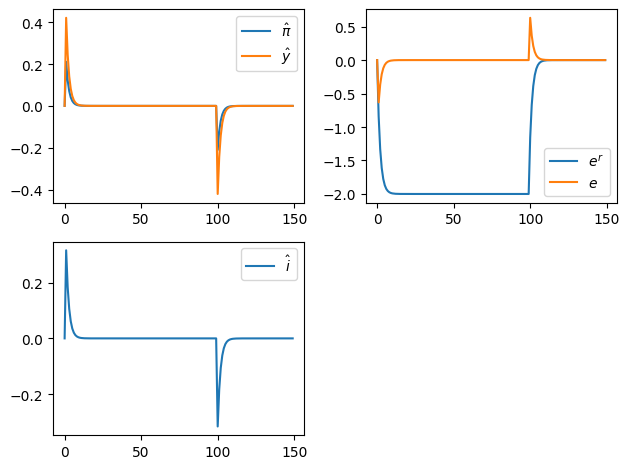

In [4]:
periods = 150 # Choose amount of periods to plot
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,periods,1),model.path.pihat[:periods],label=r'$\hat{\pi}$')
ax.plot(range(0,periods,1),model.path.yhat[:periods],label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,periods,1),model.path.er[:periods],label=r'$e^r$')
ax.plot(range(0,periods,1),model.path.e[:periods],label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,3)
ax.plot(range(0,periods,1),model.path.ihat[:periods],label=r'$\hat{i}$')
ax.legend(frameon=True)
fig.tight_layout()

As we can see, the shock creates a sudden outputgap, which will make the prices increase as a result of increased demand. Furthermore when $\pi > \pi^f$ the competitiveness of the domestic economy falls since the domestic goods gets relatively more expensive compare to foreign goods. The CB reacts by increasing the nominal interest rate, to mitigate the outputgap, and slowly decreases it until the we are back in equilibrium. Interestingly, the real exchange rate falls and stays low during the entire period of the shock. From (8), we see, that the real rate falls as a result of increased rate of depriciation of the nominal exchange rate, $\Delta e$, and furthermore since $\pi > \pi^f$.

Lets compare the response in the strict inflation target model, where $b=0$.

In [5]:
model.par.b = 0
model.shocks(1,100,1,z=True)
model.solve()

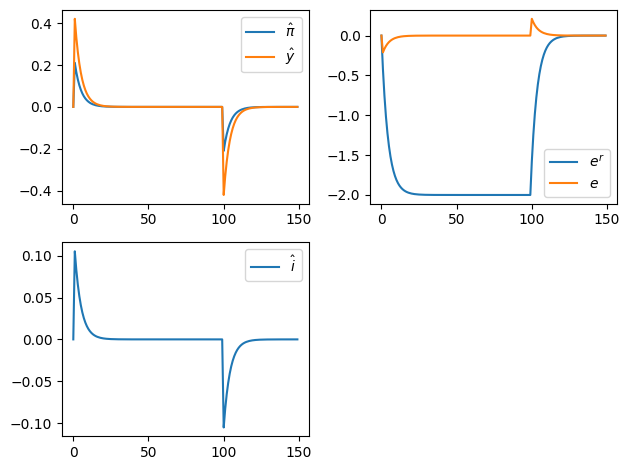

In [6]:
periods = 150 # Choose amount of periods to plot
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,periods,1),model.path.pihat[:periods],label=r'$\hat{\pi}$')
ax.plot(range(0,periods,1),model.path.yhat[:periods],label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,periods,1),model.path.er[:periods],label=r'$e^r$')
ax.plot(range(0,periods,1),model.path.e[:periods],label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,3)
ax.plot(range(0,periods,1),model.path.ihat[:periods],label=r'$\hat{i}$')
ax.legend(frameon=True)
fig.tight_layout()

The nominal exhangerate changes less, while the speed of convergence of the variables generally becomes slower. This is more so the case for the output gap than the inflation gap, as expected, since the CB is only targeting inflation. Because the CB only cares about inflation gaps, they only increase the interest rate by half, and as such the nominal rate also approximately only falls by half. Interestingly the real rate still falls the same, and during the entire period. 

Now we turn to a negative supply shock for a similar timeframe.

In [7]:
# Reset shock variables and b
model = ASAD_class()
model.par.b = 0.5 
model.shocks(1,100,1,s=True)
model.solve()

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


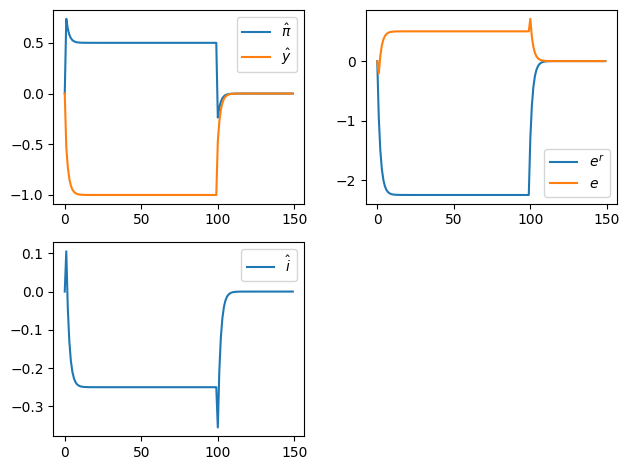

In [8]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,periods,1),model.path.pihat[:periods],label=r'$\hat{\pi}$')
ax.plot(range(0,periods,1),model.path.yhat[:periods],label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,periods,1),model.path.er[:periods],label=r'$e^r$')
ax.plot(range(0,periods,1),model.path.e[:periods],label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,3)
ax.plot(range(0,periods,1),model.path.ihat[:periods],label=r'$\hat{i}$')
ax.legend(frameon=True)
fig.tight_layout()

The CB mainly affects the demand side of the economy. The supply side shock results in increased prices, while the outputgap becomes negative. The CB first increase the interest rate to mitigate the increased inflation by dampning demand, this however further affects the outputgap negatively, and to mitigate the output gap, the CB decreases the interest rate. When the shock disappears, the reverse happens. There are two effects which happens to the exchange rate plot. Firstly the nominal exchange rate, follows the nominal interest rate exactly. When the nominal rate increases it creates increased demand for domestic currency from capital inflow, and conversely when the interest rate falls. The real exchange rate falls because of decreased competitiveness due to relatively higher domestic inflation. 

To see the importance of the size of the b parameter (how much the CB targets output), we run the shock again with b=0.9

In [9]:
# Reset shock variables and b
model = ASAD_class()
model.par.b = 0.9 
model.shocks(1,100,1,s=True)
model.solve()

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


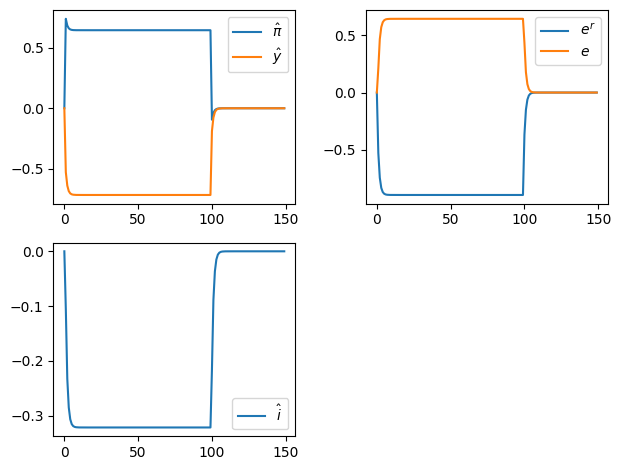

In [10]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,periods,1),model.path.pihat[:periods],label=r'$\hat{\pi}$')
ax.plot(range(0,periods,1),model.path.yhat[:periods],label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,periods,1),model.path.er[:periods],label=r'$e^r$')
ax.plot(range(0,periods,1),model.path.e[:periods],label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,3)
ax.plot(range(0,periods,1),model.path.ihat[:periods],label=r'$\hat{i}$')
ax.legend(frameon=True)
fig.tight_layout()

The difference in response is quite clear. We still have increased prices and a negative output gap as before. But the size of the outputgap is smaller, due to the CB valuing output stability higher than inflation stability. It is perhaps more clearly depicted by the nominal interest rate graph, where the CB immediately lowers the interest rate and to a higher degree. This results in an increased rate of depreciation of the nominal exchange rate, and a higher inflation. Interestingly, as a result of increased nominal exchange rate, the real rate falls significantly less. 

## 2. <a id='toc2_'></a>[Stochastic Shocks](#toc0_)

Having a constant shock makes the analysis simple, but in the real world shocks appear randomnly, oftenly, and are of different magnitudes. The following sections, analyzes the cases where the shocks are modelled as stochastic. Now the first way we have implemented this, is by creating a vector with the length of the analysis period (500). Each element of the vector is an independent draw from a standard gaussian distribution. First we consider a demand shock.

In [11]:
# Reset shock variables
model = ASAD_class()
model.par.b = 0.5 
# Load stochastic demand shocks and solve model
model.stochastic_shocks(0,1,z=True)
model.solve()

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


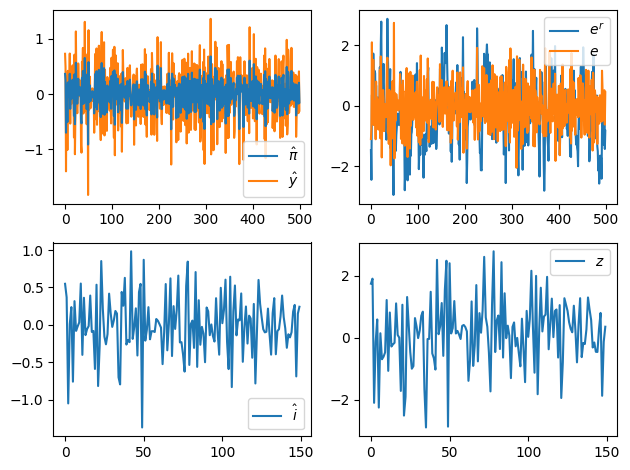

In [12]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$', zorder=10)
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,3)
ax.plot(range(0,periods,1),model.path.ihat[:periods],label=r'$\hat{i}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,4)
ax.plot(range(0,periods,1),model.path.z[:periods],label=r'$z$')
ax.legend(frameon=True)
fig.tight_layout()

Similarly to the simple shocks, the output gap generally has bigger variance, but as we saw this is dependent on the size of the b parameter. The real and nominal exhange rates fluctate to uphold the UIP condition in (4) given the changes in output and inflation. Fluctuations in the real exchange rate seem more persistent, and from (8) it's evident that this is the result of the autoregressive nature of how the real exchange rate is determined.

Next we consider a model with continous stochastic shocks to the supply side.

In [13]:
# Reset shock variables
model = ASAD_class()
# Load stochastic supply shocks and solve model
model.stochastic_shocks(0,1,s=True)
model.solve()

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


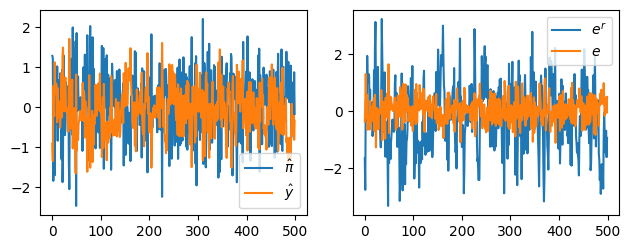

In [14]:
fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

This time we see the variance of both real exchange rate, inflation- and output gap increase compared to the demand shock situation, reflecting that the central bank has less influence on the supply side of the economy. Further, the variance in inflation gap is now higher than for the output gap, reflecting that the supply side shock only affects output indirectly through its effect on inflation.

## 3. <a id='toc3_'></a>[Persistent, stochastic shocks (AR)](#toc0_)

Overall it is hard to analyze the workings of stochastic shocks to the economy due to the amount of noise, so for this section we implement a stochastic AR(1) process, which seem more realistic. We set the autoregressive parameter, $\rho$ to 0.9 < 1, such that the errors aren't a random walk. Similar to the case in section 2. each element of the shock vector contains a new random draw from standard normal distribution, as well as an AR(1) term. For the demand side shocks, this can be writtena as $z_t = \rho \cdot z_{t-1}+e_t$ with $e_t$ being i.i.d. $\mathcal{N}(0,1)$.

### 3.1. <a id='toc3_1_'></a>[Demand shocks as an AR-process](#toc0_)

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


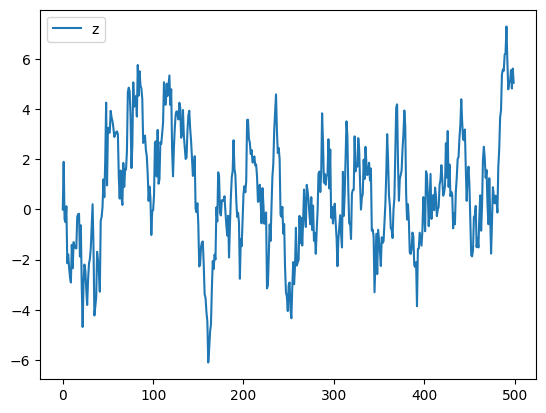

In [15]:
# Reset shock variables
model = ASAD_class()
# Load stochastic AR shocks and plot them
model.AR_shocks(rho=0.9,sd=1,z=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.z,label=r'z')
ax.legend(frameon=True)

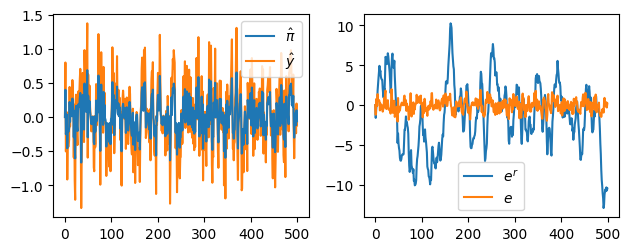

In [16]:
model.solve()

fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$', zorder=10)
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')

ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

Again we see that the central bank is relatively succesful in limiting the effects of shocks to the demand side of the economy, with output and inflation gap staying within 1.5/-1.5. Most of the effect of the shock is thus captured by movements in the real exchange rate, which exhibits a pattern similar to the path of the shock, but inversed.

### 3.2. <a id='toc3_2_'></a>[Supply shocks as an AR-process](#toc0_)

To follow up, we now consider a similar AR-shock process to the supply side. Note that we use the same seed, meaning that the following $s_t$ process is identical, to the $z_t$ process, in the previous section. This is done to compare the responses and effects more consistently.

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


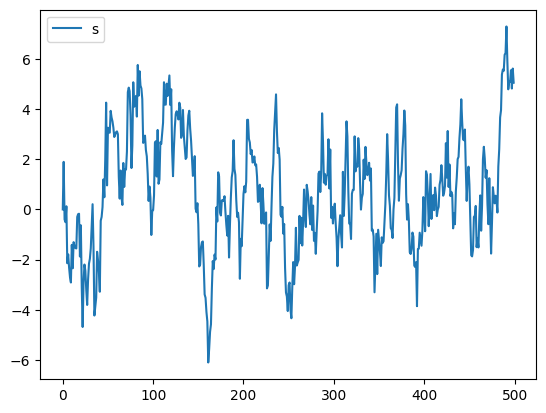

In [17]:
# Reset shock variables
model = ASAD_class()
# Supply AR shock
model.AR_shocks(rho=0.9,sd=1,s=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.s,label=r's')
ax.legend(frameon=True)

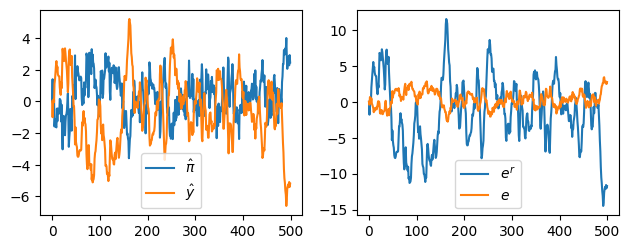

In [18]:
model.solve()

fig = plt.figure()
ax = fig.add_subplot(2,2,1)
ax.plot(range(0,par.Tpath,1),model.path.pihat,label=r'$\hat{\pi}$')
ax.plot(range(0,par.Tpath,1),model.path.yhat,label=r'$\hat{y}$')
ax.legend(frameon=True)
fig.tight_layout()

ax = fig.add_subplot(2,2,2)
ax.plot(range(0,par.Tpath,1),model.path.er,label=r'$e^r$')
ax.plot(range(0,par.Tpath,1),model.path.e,label=r'$e$')
ax.legend(frameon=True)
fig.tight_layout()

The demand side shocks exhibits larger, more persistent effects on inflation and output gap, but also through indirect effects, on the exhange rates. Inflation generally moves in the same direction as the shock and a positive supply shock can thus be thought of as rising production costs, increasing the price level in the economy. The output gap on the other hand moves in the opposite direction, reflecting the negative effect of a rising interest rate and the exchange rate effects on output.

## 4. <a id='toc4_'></a>[The super, social planner, living in an AR-world](#toc0_)

The analysis so far have focused on the CB responses to both demand and supply shocks. As we have seen, both through the different exercises, and directly from the Taylor Rule, the size of the parameters $b,h$, determine the weight the CB puts on the outputgap and inflation target differences, respectively, in regards to how much/how little, the interest rate should adjust. 

In the following section, we consider how a social planner controlling the h and b parameters, could optimize these in an economy with persistent supply or demand shocks. To do so, we minimize a social loss function, given by the (quadratic) deviations from structural output and inflation over the entire period.

### 4.1. <a id='toc4_1_'></a>[Social planner with supply shocks as an AR-process](#toc0_)

initializing the model:
Setting up model with standard parameters
Allocating paths for output, inflation, nominal exchange rate and real exchange rate


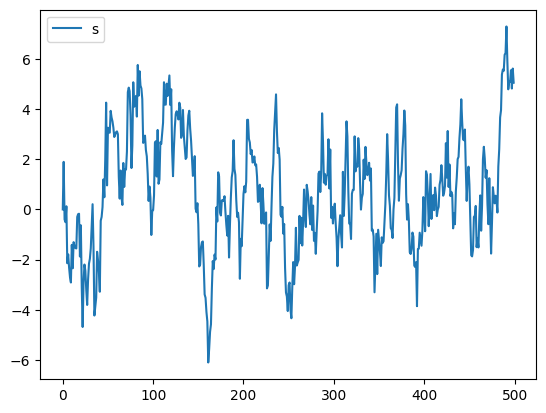

In [19]:
# Reset shock variables
model = ASAD_class()
# AR supply shock
model.AR_shocks(rho=0.9,sd=1,s=True)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(range(0,par.Tpath),model.path.s,label=r's')
ax.legend(frameon=True)

In [20]:
# Create lists for storing social loss, as well as lists of possible h and b values
sl = np.zeros((20,20))
possible_h = np.linspace(0,2,num=20)
possible_b = np.linspace(0,2,num=20)

# Define objective function to be minimized
def slhb(x):
    h, b = x
    model.par.h = h
    model.par.b = b
    model.solve()
    return model.compute_social_loss()

In [21]:
# Variables to store results
sl_best = np.inf
h_best = np.nan
b_best = np.nan

# Create a matrix to store the results
sl = np.zeros((len(possible_h), len(possible_b)))

# Minimizing using search function
for i, h in enumerate(possible_h):
    for j, b in enumerate(possible_b):
        x = np.array([h, b])
        sl_value = slhb(x)  # Compute social loss for (h, b)
        sl[i, j] = sl_value
        
        if sl_value < sl_best:
            sl_best = sl_value
            h_best = h
            b_best = b

print(h_best, b_best, sl_best)

0.3157894736842105 1.5789473684210527 2314.5598402711526


In [22]:
# Alternative using a solver
x_init = np.array([0,0])
social_loss = scipy.optimize.minimize(slhb,x0=x_init, method='nelder-mead')
# Access the optimized parameters
optimized_parameters = social_loss.x
print("Optimized parameters (h, b):", optimized_parameters)

# Access the minimum value of the objective function
min_loss = social_loss.fun
print("Minimum value of the objective function:", min_loss)

Optimized parameters (h, b): [0.37342521 1.69117551]
Minimum value of the objective function: 2314.5271631039413


The cell below calculates social loss for a larger grid (50x50), so it takes a while to load. Makes it easier to see the slopes of the surfaceplot

In [23]:
# Generate values for h and b
h_values = np.linspace(0, 2, num=50)
b_values = np.linspace(0, 2, num=50)

# Create a grid of h and b values
H, B = np.meshgrid(h_values, b_values)

# Compute the social loss for each combination of h and b
social_loss_values = np.zeros_like(H)
for i in range(len(h_values)):
    for j in range(len(b_values)):
        model.par.h = H[i, j]
        model.par.b = B[i, j]
        model.solve()
        social_loss_values[i, j] = model.compute_social_loss()


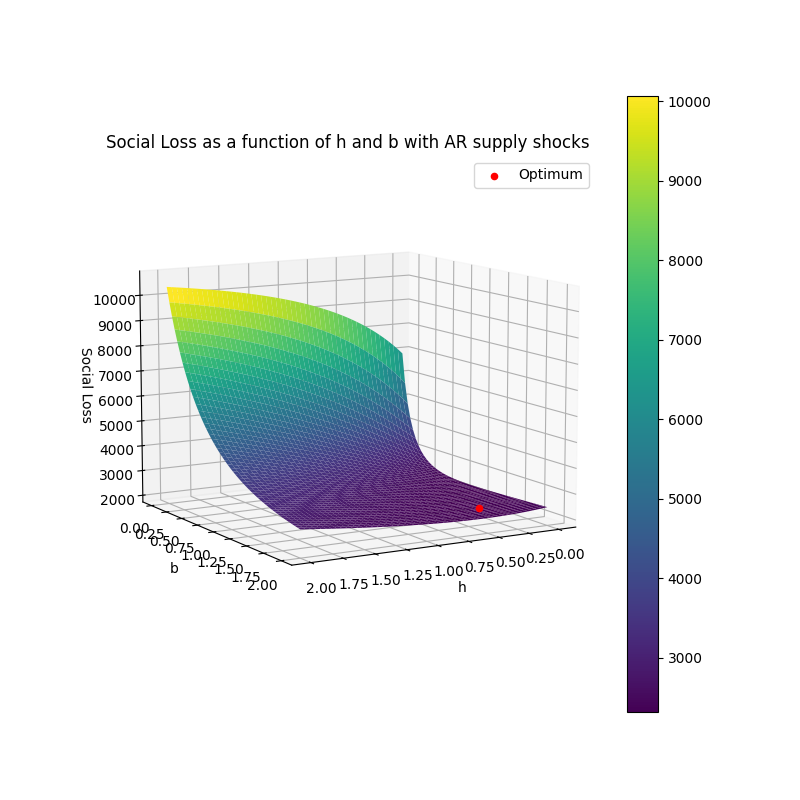

In [24]:
# Plot the surface
%matplotlib ipympl
fig = plt.figure(figsize=(8, 8)) 
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)
surf = ax.plot_surface(H, B, social_loss_values, cmap='viridis')
# Plot optimum point
ax.scatter(optimized_parameters[0], optimized_parameters[1], min_loss, color='red', label='Optimum', s=20)
# Set labels and title
ax.set_xlabel('h')
ax.set_ylabel('b')
ax.set_zlabel('Social Loss')
ax.set_title('Social Loss as a function of h and b with AR supply shocks')

fig.colorbar(surf)
ax.legend()

ax.view_init(elev=10, azim=60)
plt.show()

Given the optimal values of b and h, the social planner would put more weight on targeting output rather than inflation.

### 4.2. <a id='toc4_2_'></a>[Social planner with demand shocks as an AR-process](#toc0_)

In [25]:
# Reset shock variables
model = ASAD_class(do_print=False)
# AR demand shock
model.AR_shocks(rho=0.9,sd=1,z=True)

# Optimize
social_loss_d = scipy.optimize.minimize(slhb,x0=x_init, method='nelder-mead')
# Access the optimized parameters
optimized_parameters_d = social_loss_d.x
print("Optimized parameters (h, b):", optimized_parameters_d)
# Access the minimum value of the objective function
min_loss_d = social_loss_d.fun
print("Minimum value of the objective function:", min_loss_d)

Optimized parameters (h, b): [0.29851383 1.61234401]
Minimum value of the objective function: 121.44254872292987


In [26]:
# Compute the social loss for each combination of h and b
social_loss_values_d = np.zeros_like(H)
for i in range(len(h_values)):
    for j in range(len(b_values)):
        model.par.h = H[i, j]
        model.par.b = B[i, j]
        model.solve()
        social_loss_values_d[i, j] = model.compute_social_loss()

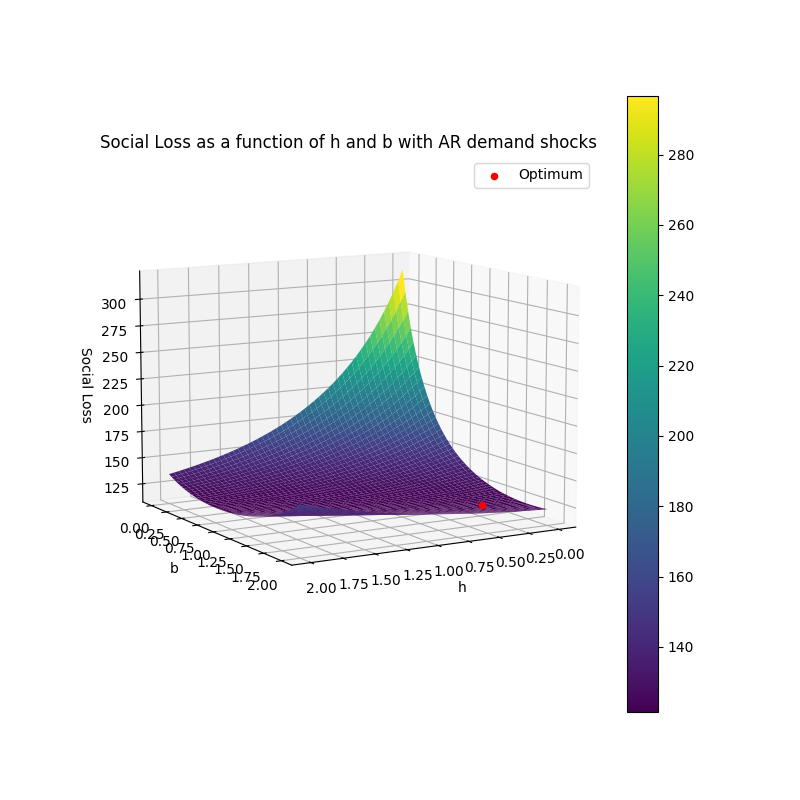

In [27]:
fig = plt.figure(figsize=(8, 8)) 
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)
surf = ax.plot_surface(H, B, social_loss_values_d, cmap='viridis')
# Plot optimum point
ax.scatter(optimized_parameters_d[0], optimized_parameters_d[1], min_loss_d, color='red', label='Optimum', s=20)
# Set labels and title
ax.set_xlabel('h')
ax.set_ylabel('b')
ax.set_zlabel('Social Loss')
ax.set_title('Social Loss as a function of h and b with AR demand shocks')

fig.colorbar(surf)
ax.legend()

ax.view_init(elev=10, azim=60)
plt.show()

Interestingly the choice of h and b values do not differ much between the two situations, with the social planner preferring a b value around 1.6-1.7, and an h value around 0.3-0.4, thus putting more weight on output in both cases. One big difference however, is the associated social loss, which over the 500 periods is about 20 times larger for the situation with shocks to the supply side of the economy. This reflects the central bank's relatively larger power to impact the aggregate demand, while supply is less sensitive to monetary policy.